# **Time Series Anomaly Detection using LSTM Autoencoer**


## About Authur: 
- Name : Muhammad Muneebullah
### 🙋‍♂️ Let's Connect!

Stay in touch for more awesome data stories and projects! 🚀  
You can find me on:

---

| 🔗 Platform | 🌐 Link |
|------------|---------|
| 👔 **LinkedIn** | [Visit my profile](https://www.linkedin.com/in/muneeb-ullah-open-to-internships-241393337/) |
| 🧠 **Kaggle** | [Check out my notebooks](https://www.kaggle.com/muneebullahmuneeb) |
| 📧 **Email** | [Contact me in Email](muneebullahmuneeb63@gmail.com) |

## About Dataset:
The Numenta Anomaly Benchmark (NAB) is a novel benchmark for evaluating algorithms for anomaly detection in streaming, online applications. It is comprised of over 50 labeled real-world and artificial timeseries data files plus a novel scoring mechanism designed for real-time applications. All of the data and code is fully open-source, with extensive documentation, and a scoreboard of anomaly detection algorithms:Dataset Source: https://github.com/numenta/NAB The full dataset is included here, but please go to the repo for details on how to evaluate anomaly detection algorithms on NAB.

## NAB Data Corpus:
The NAB corpus of 58 timeseries data files is designed to provide data for research in streaming anomaly detection. It is comprised of both real-world and artifical timeseries data containing labeled anomalous periods of behavior. Data are ordered, timestamped, single-valued metrics. All data files contain anomalies, unless otherwise noted.

The majority of the data is real-world from a variety of sources such as AWS server metrics, Twitter volume, advertisement clicking metrics, traffic data, and more. All data is included in the repository, with more details in the data readme. We are in the process of adding more data, and actively searching for more data. Please contact us at [nab@numenta.org](mailto:nab@numenta.org) if you have similar data (ideally with known anomalies) that you would like to see incorporated into NAB.

The NAB version will be updated whenever new data (and corresponding labels) is added to the corpus; NAB is currently in v1.0.

## Problem Statment:
**Build an LSTM Autoencoder to detect unusual patterns (anomalies) in NAB time-series data using reconstruction error analysis. The goal is to learn normal behavior and identify sequences that significantly deviate from it.**

## Using Libraries:

- Numpy 
- Matplotlib
- seaborn 
- Pandas
- Sklearn
- Tensorflow

<div style="font-family: 'Times New Roman', serif; background-color: #1E3A8A; color: #FF6347; padding: 15px 25px; font-size: 28px; font-weight: bold; border-radius: 15px; text-align: center;">
    <span style="color: #87CEFA;">Step 1</span>: Import Necessary Libraries
</div>

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

<div style="font-family: 'Times New Roman', serif; background-color: #1E3A8A; color: #FF6347; padding: 15px 25px; font-size: 28px; font-weight: bold; border-radius: 15px; text-align: center;">
    <span style="color: #87CEFA;">Step 2</span>: Load Dataset
</div>

In [2]:
df = pd.read_csv('art_daily_jumpsdown.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

,timestamp,value
0,2014-04-01 00:00:00,18.090486
1,2014-04-01 00:05:00,20.359843
2,2014-04-01 00:10:00,21.105470
3,2014-04-01 00:15:00,21.151585
4,2014-04-01 00:20:00,18.137141


<div style="font-family: 'Times New Roman', serif; background-color: #1E3A8A; color: #FF6347; padding: 15px 25px; font-size: 28px; font-weight: bold; border-radius: 15px; text-align: center;">
    <span style="color: #87CEFA;">Step 3</span>: Understand our dataset
</div>

- Let's check the shape of our dataset

In [3]:
print("The number of Rows in our Dataset is", df.shape[0], "and number of columns in our Dataset is", df.shape[1])

The number of Rows in our Dataset is 4032 and number of columns in our Dataset is 2


- Let's check the basic info in our Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  4032 non-null   datetime64[ns]
 1   value      4032 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 63.1 KB


- Now the Important part is checking the Null or Missing values in our Dataset:

In [5]:
df.isnull().sum()

timestamp    0
value        0
dtype: int64

Congratulates! our Dataset has no missing values.

- Now we check the statistical summary of our dataset

In [6]:
df.describe()

,timestamp,value
count,4032,4032.000000
mean,2014-04-07 23:57:30,41.509772
min,2014-04-01 00:00:00,18.002040
25%,2014-04-04 11:58:45,19.986745
50%,2014-04-07 23:57:30,21.637211
75%,2014-04-11 11:56:15,74.864803
max,2014-04-14 23:55:00,87.998382
std,NaN,27.512033


- Let's visualize the values in our dataset 

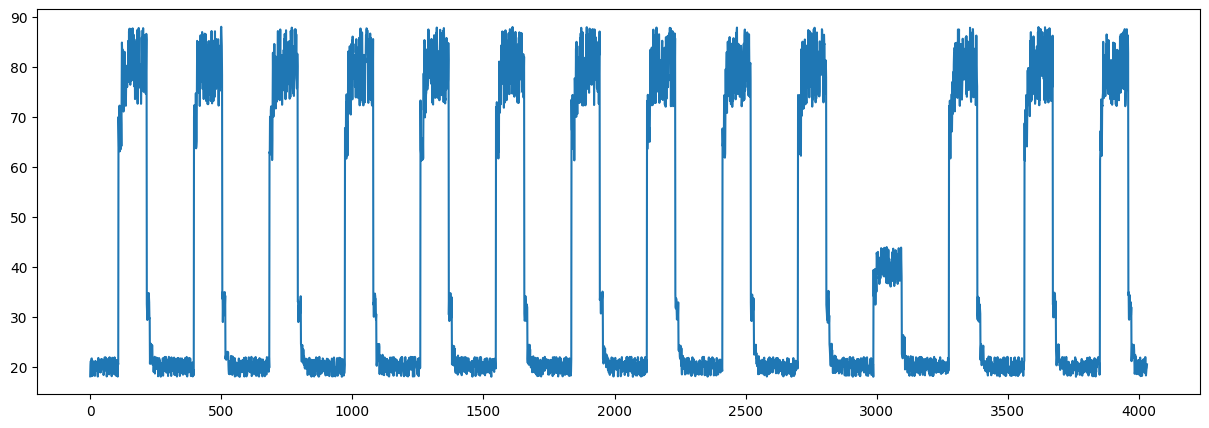

In [7]:
df['value'].plot(figsize=(15,5))
plt.show()


- Here the 11 Cycle show us there is anomaly in our dataset.

<div style="font-family: 'Times New Roman', serif; background-color: #1E3A8A; color: #FF6347; padding: 15px 25px; font-size: 28px; font-weight: bold; border-radius: 15px; text-align: center;">
    <span style="color: #87CEFA;">Step 4</span>: Preprocess our Dataset
</div>

- Let's fetch the Time interval for every cycle in our dataset.

In [8]:
print("The Time Interval for Ecah cyclr=e in our Dataset is: ", df['timestamp'].iloc[1] - df['timestamp'].iloc[0])

The Time Interval for Ecah cyclr=e in our Dataset is:  0 days 00:05:00


- Let's check the duplicate row in our Dataset.

In [9]:
df.duplicated().sum()

np.int64(0)

- Here we there is no duplicate row in our Dataset.

In [10]:
df = df.sort_values('timestamp')

In [11]:
df.index.is_monotonic_increasing

True

- Here is the important point for anomaly Detection, That is scaling the values.

In [12]:
scaler = MinMaxScaler()
df['value_scaled'] = scaler.fit_transform(df[['value']])

- Here we see our values are scaled.

In [13]:
df.head()

,timestamp,value,value_scaled
0,2014-04-01 00:00:00,18.090486,0.001264
1,2014-04-01 00:05:00,20.359843,0.033685
2,2014-04-01 00:10:00,21.105470,0.044337
3,2014-04-01 00:15:00,21.151585,0.044996
4,2014-04-01 00:20:00,18.137141,0.001930


- Here is our important part for train and test split our dataset.

In [14]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [15]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (3225, 3)
Test Shape: (807, 3)


In [16]:
train_values = train['value_scaled'].values
test_values = test['value_scaled'].values

In [17]:
print(train_values.shape)
print(test_values.shape)

(3225,)
(807,)


- Here is the vey important step is the Sequence Length thats very helpful for the LSTM for anomaly detection and it is 30.

In [18]:
SEQ_LEN = 30

In [19]:
import numpy as np

def create_sequences(data, seq_length):
    
    sequences = []
    
    for i in range(len(data) - seq_length):
        
        seq = data[i:i + seq_length]
        
        sequences.append(seq)
    
    return np.array(sequences)

In [20]:
SEQ_LENGTH = 30

X_train = create_sequences(train_values, SEQ_LENGTH)
X_test = create_sequences(test_values, SEQ_LENGTH)

In [21]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (3195, 30)
X_test Shape: (777, 30)


In [22]:
print(X_train[0])


[0.00126358 0.03368466 0.04433703 0.04499586 0.00193011 0.05176871
 0.05245655 0.03205198 0.02751991 0.00253485 0.0320842  0.02336517
 0.04413353 0.02305112 0.03903466 0.00576591 0.00756853 0.00795471
 0.00257245 0.03090555 0.04534281 0.03485332 0.03282714 0.03886568
 0.01938017 0.02065503 0.01793009 0.04066492 0.00920793 0.0007152 ]


In [23]:
print(X_train.shape)
print(X_test.shape)

(3195, 30)
(777, 30)


In [24]:
print(X_train[0].shape)

(30,)


<div style="font-family: 'Times New Roman', serif; background-color: #1E3A8A; color: #FF6347; padding: 15px 25px; font-size: 28px; font-weight: bold; border-radius: 15px; text-align: center;">
    <span style="color: #87CEFA;">Step 5</span>: LSTM Model
</div>

- Import libraries

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import RepeatVector
from tensorflow.keras.layers import TimeDistributed
import random
import tensorflow as tf

- Make the model for anomaly Detection.

In [26]:

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
model = Sequential()


# Encoder
model.add(
    LSTM(
        64,
        activation='relu',
        input_shape=(X_train.shape[1], 1),
        return_sequences=False
    )
)

# Repeat
model.add(
    RepeatVector(X_train.shape[1])
)

# Decoder
model.add(
    LSTM(
        64,
        activation='relu',
        return_sequences=True
    )
)

# Output Layer
model.add(
    TimeDistributed(
        Dense(X_train.shape[2])
    )
)

c:\Users\M-TT\miniconda3\envs\tf2_dl\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - loss: 0.1137 - val_loss: 0.0041
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0397 - val_loss: 0.0055
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0300 - val_loss: 0.0066
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0242 - val_loss: 0.0055
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0316 - val_loss: 0.0086
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0243 - val_loss: 0.0058
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0219 - val_loss: 0.0062
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0192 - val_loss: 0.0179
Epoch 9/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0566 - val_loss: 0.0137
Epoch 10/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0224 - val_loss: 0.0085
Epoch 11/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0213 - val_loss: 0.0067
Epoch 12/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.

In [30]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

In [31]:
history.history['loss'][-1]

0.01804041676223278

In [32]:
history.history['val_loss'][-1]

0.020823467522859573

In [33]:
X_train_pred = model.predict(X_train)

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step


- Let's check the recontruction error

In [34]:
import numpy as np

train_mse = np.mean(
    np.power(X_train - X_train_pred, 2),
    axis=(1, 2)
)

In [35]:
print(train_mse[:10])

[0.00279819 0.00264718 0.00264234 0.0026971  0.00274996 0.00260629
 0.00265366 0.00269965 0.0027135  0.00276733]


- Now we check our threshold.

In [36]:
threshold = np.mean(train_mse) + 3 * np.std(train_mse)

print("Threshold =", threshold)

Threshold = 0.14072698262487304


In [37]:
anomalies = train_mse > threshold

print("Total Anomalies:", anomalies.sum())

Total Anomalies: 91


- Here we see our total anomalies

In [38]:
anomaly_indices = np.where(anomalies)[0]

print(anomaly_indices[:10])

[199 200 201 202 203 204 205 206 207 208]


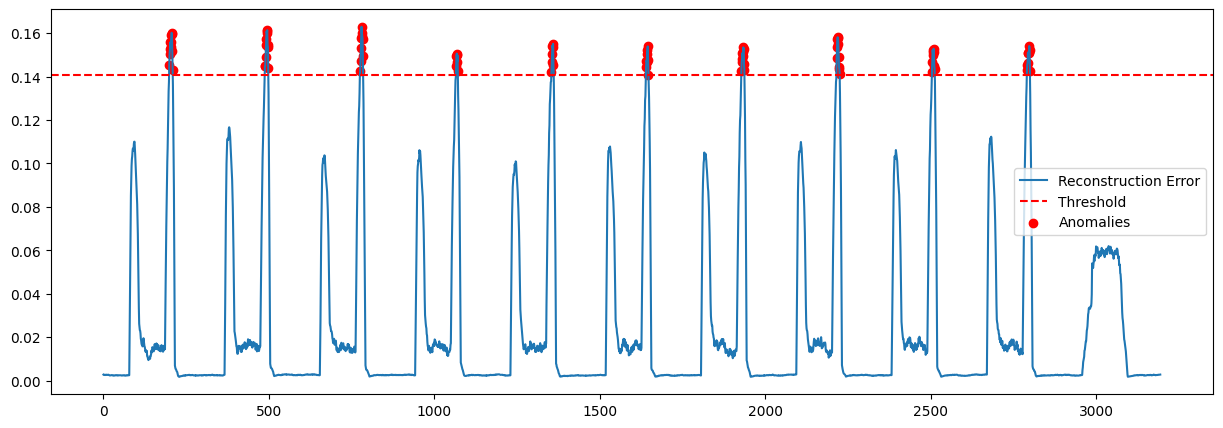

In [39]:
plt.figure(figsize=(15,5))

plt.plot(train_mse, label='Reconstruction Error')

plt.axhline(
    threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)

plt.scatter(
    anomaly_indices,
    train_mse[anomaly_indices],
    color='red',
    label='Anomalies'
)

plt.legend()
plt.show()

In [40]:
# predict on test sequences, compute MSE per sequence and map sequence indices to test rows
X_test_pred = model.predict(X_test)
test_mse = np.mean(np.power(X_test - X_test_pred, 2), axis=(1, 2))

anomaly_mask_test = test_mse > threshold
anomaly_seq_indices = np.where(anomaly_mask_test)[0]

# map sequence index i to the corresponding timestamp row at the end of the sequence: i + SEQ_LENGTH - 1
anomaly_points = test.iloc[anomaly_seq_indices + SEQ_LENGTH - 1]

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


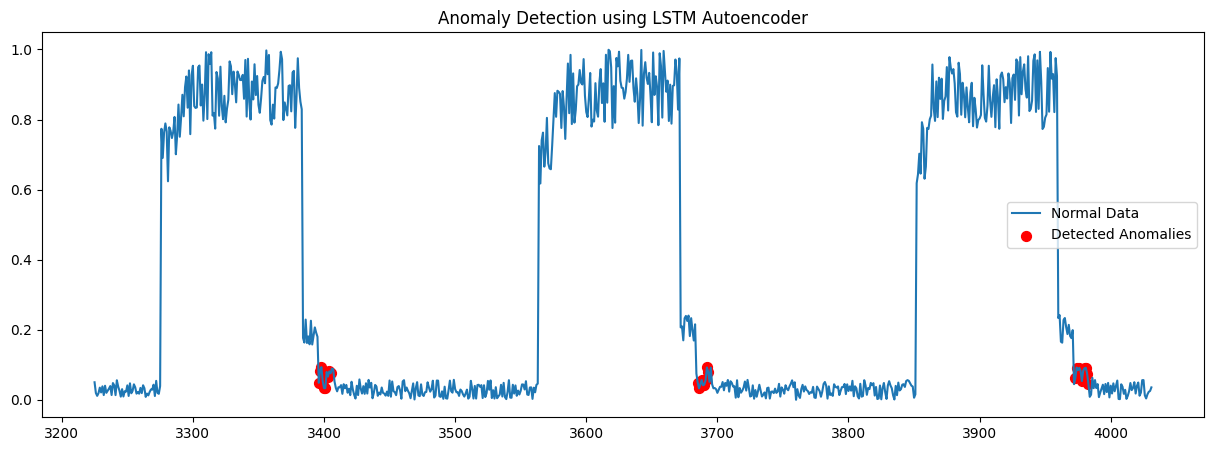

In [41]:
plt.figure(figsize=(15,5))

plt.plot(
    test.index,
    test['value_scaled'],
    label='Normal Data'
)

plt.scatter(
    anomaly_points.index,
    anomaly_points['value_scaled'],
    color='red',
    s=50,
    label='Detected Anomalies'
)

plt.legend()
plt.title('Anomaly Detection using LSTM Autoencoder')

plt.show()

In [42]:
print("Train MSE Mean:", train_mse.mean())
print("Test MSE Mean:", test_mse.mean())

print("Train MSE Max:", train_mse.max())
print("Test MSE Max:", test_mse.max())

print("Threshold:", threshold)

Train MSE Mean: 0.024946897127019016
Test MSE Mean: 0.027862662452526398
Train MSE Max: 0.16292616684033726
Test MSE Max: 0.15689117468167374
Threshold: 0.14072698262487304


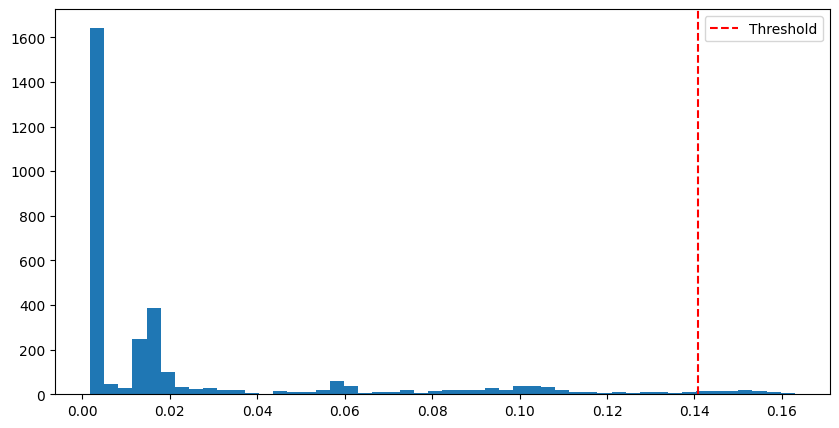

In [43]:
plt.figure(figsize=(10,5))
plt.hist(train_mse, bins=50)
plt.axvline(
    threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)
plt.legend()
plt.show()

## Conclusion

In this project, an LSTM Autoencoder was developed to detect anomalies in time-series data from the NAB dataset. The model learned normal temporal patterns and identified unusual sequences using reconstruction error analysis. A statistical threshold was used to flag anomalies, and the detected anomalies were successfully visualized on the original time series.

## ⭐ Support

If you found this notebook helpful and learned something new, please consider giving it an upvote. Your support motivates me to create more data science and deep learning projects. Thank you! 😊